# **Leak Detection in Water Pipelines**

This project builds an end-to-end deep learning system for detecting pipe damage using computer vision. I used a Kaggle dataset containing damaged and undamaged pipe images. The images are preprocessed and split into training and validation sets. I used transfer learning with a pretrained ResNet18 model and fine-tuned the final layer for binary classification. The model achieved around 90% validation accuracy. Finally, I deployed the trained model using Flask, allowing users to upload pipe images through a web interface and receive predictions with confidence scores.

# 1. Install Dependencies

In [1]:
!pip install torch torchvision matplotlib scikit-learn seaborn pillow

# 2. Import Libraries

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

# 3. Device Configuration

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# 4. Dataset Path
Download dataset from Kaggle and extract.

In [5]:
# Install Kaggle API
!pip install kaggle

# Upload Kaggle API Key
from google.colab import files
files.upload()

# Configure Kaggle
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!mv kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json


# Download Dataset from Kaggle
!kaggle datasets download -d mitheshreddy/pipe-images-dataset

# Unzip Dataset
!unzip pipe-images-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mitheshreddy/pipe-images-dataset
License(s): unknown
 97% 557M/577M [00:01<00:00, 331MB/s]
100% 577M/577M [00:01<00:00, 430MB/s]
Archive:  pipe-images-dataset.zip
  inflating: DAMAGED/IMG_20211114_132530.jpg  
  inflating: DAMAGED/IMG_20211114_132557.jpg  
  inflating: DAMAGED/IMG_20211114_132602.jpg  
  inflating: DAMAGED/IMG_20211114_132637.jpg  
  inflating: DAMAGED/IMG_20211114_132647.jpg  
  inflating: DAMAGED/IMG_20211114_132741.jpg  
  inflating: DAMAGED/IMG_20211114_132747.jpg  
  inflating: DAMAGED/IMG_20211114_132829.jpg  
  inflating: DAMAGED/IMG_20211114_132833.jpg  
  inflating: DAMAGED/IMG_20211114_132838.jpg  
  inflating: DAMAGED/IMG_20211114_132845.jpg  
  inflating: DAMAGED/IMG_20211114_132853.jpg  
  inflating: DAMAGED/IMG_20211114_133012.jpg  
  inflating: DAMAGED/IMG_20211114_133023.jpg  
  inflating: DAMAGED/IMG_20211114_133031.jpg  
  inflating: DAMAGED/IMG_20211114_133055.jpg  
  infl

# 5. Data Preprocessing (Transforms)

In [17]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# 6. Load Dataset

In [19]:
import shutil

# Create a new directory for the dataset to avoid conflicts with other folders
os.makedirs("dataset_images", exist_ok=True)

# Move the class directories into the new dataset directory
if os.path.exists("DAMAGED"):
    shutil.move("DAMAGED", "dataset_images/DAMAGED")
if os.path.exists("UNDAMAGED"):
    shutil.move("UNDAMAGED", "dataset_images/UNDAMAGED")

dataset = datasets.ImageFolder(
    root="dataset_images",
    transform=transform
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['DAMAGED', 'UNDAMAGED']
Total Images: 730


# 7. Visualize Dataset Samples

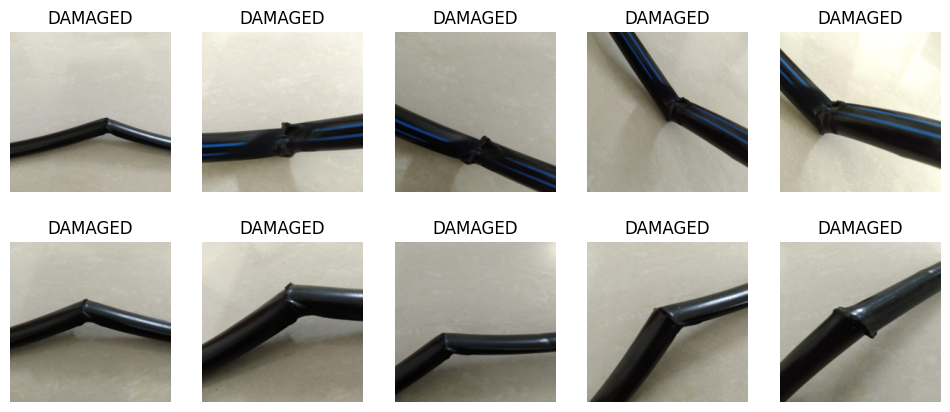

In [21]:
fig, axes = plt.subplots(2,5, figsize=(12,5))

for i, ax in enumerate(axes.flatten()):

    img, label = dataset[i]

    img = img.permute(1,2,0)

    ax.imshow(img)
    ax.set_title(dataset.classes[label])
    ax.axis("off")

plt.show()

# 8. Dataset Split (Train / Validation)

In [22]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

print("Train Size:",len(train_dataset))
print("Validation Size:",len(val_dataset))

Train Size: 584
Validation Size: 146


# 9. DataLoader

In [23]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32)

# 10. Load Transfer Learning Model (ResNet18)

In [24]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features,2)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# 11. Loss Function and Optimizer

In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=0.001)

# 12. Training Loop

In [26]:
epochs = 10

train_losses = []
val_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,labels in train_loader:

        images,labels = images.to(device),labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss/len(train_loader)

    train_losses.append(train_loss)

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in val_loader:

            images,labels = images.to(device),labels.to(device)

            outputs = model(images)

            _,predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    acc = 100*correct/total

    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}/{epochs}  Loss:{train_loss:.4f}  Val Accuracy:{acc:.2f}%")

Epoch 1/10  Loss:0.2840  Val Accuracy:91.78%
Epoch 2/10  Loss:0.0991  Val Accuracy:98.63%
Epoch 3/10  Loss:0.0681  Val Accuracy:97.26%
Epoch 4/10  Loss:0.0438  Val Accuracy:99.32%
Epoch 5/10  Loss:0.0150  Val Accuracy:99.32%
Epoch 6/10  Loss:0.0139  Val Accuracy:99.32%
Epoch 7/10  Loss:0.0107  Val Accuracy:99.32%
Epoch 8/10  Loss:0.0432  Val Accuracy:80.14%
Epoch 9/10  Loss:0.0977  Val Accuracy:97.26%
Epoch 10/10  Loss:0.1063  Val Accuracy:96.58%


# 13. Training Visualization

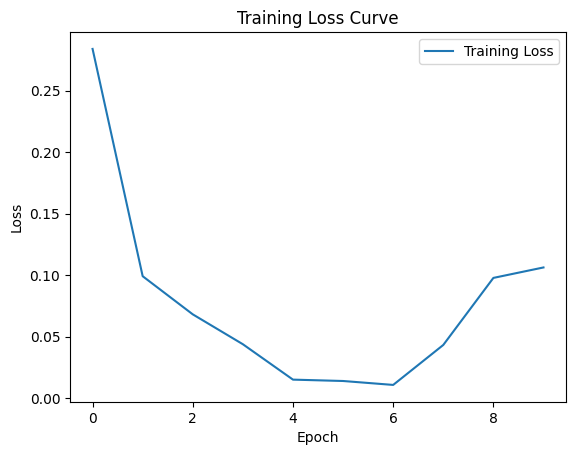

In [27]:
plt.figure()

plt.plot(train_losses,label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

plt.show()

# 14. Accuracy Visualization

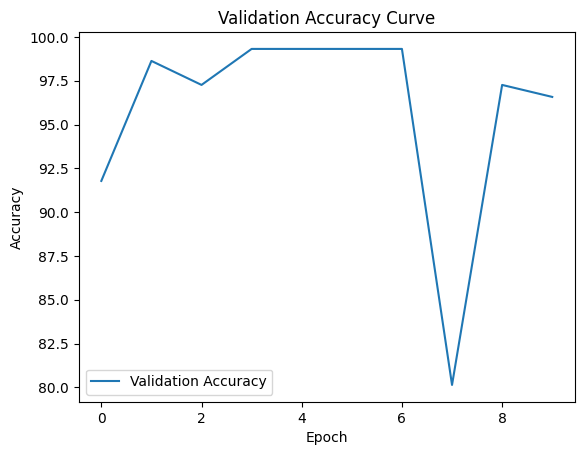

In [28]:
plt.figure()

plt.plot(val_accuracies,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Validation Accuracy Curve")

plt.legend()

plt.show()

# 15. Confusion Matrix

In [29]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _,predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())

        y_pred.extend(predicted.cpu().numpy())

# 16. Plot Confusion Matrix

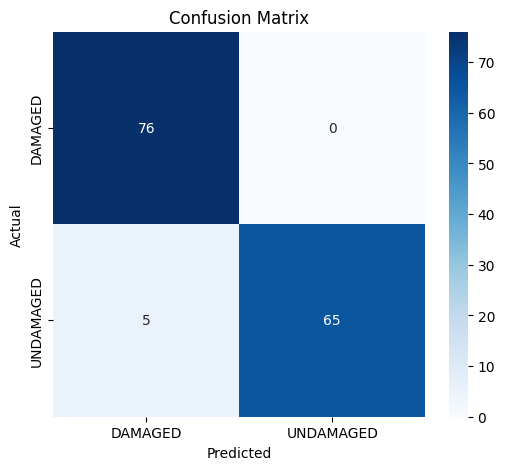

In [30]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# 17. Classification Report

In [31]:
print(classification_report(y_true,y_pred,target_names=dataset.classes))

              precision    recall  f1-score   support

     DAMAGED       0.94      1.00      0.97        76
   UNDAMAGED       1.00      0.93      0.96        70

    accuracy                           0.97       146
   macro avg       0.97      0.96      0.97       146
weighted avg       0.97      0.97      0.97       146



# 18. Save Model

In [32]:
os.makedirs("models",exist_ok=True)

torch.save(model.state_dict(),"models/pipe_damage_model.pth")

print("Model saved successfully")

Model saved successfully


# 19. Test Prediction on New Image

In [33]:
def predict_image(image_path):

    img = Image.open(image_path).convert("RGB")

    img = transform(img).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(img)

        prob = torch.softmax(output,dim=1)

        conf,pred = torch.max(prob,1)

    classes = dataset.classes

    print("Prediction:",classes[pred.item()])

    print("Confidence:",conf.item()*100,"%")

In [35]:
predict_image("dataset_images/UNDAMAGED/20211113_161701.jpg")

Prediction: UNDAMAGED
Confidence: 70.96979022026062 %
